In [26]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.build_features import prepare_training_data
from src.models.train_model import train_model, save_model
from src.visualization.visualize import (
    plot_model_performance, plot_residuals, plot_feature_importance
)

sns.set_theme(style="whitegrid")

In [27]:
# Load the features we created in notebook 02
features_df = pd.read_csv("../data/processed/driver_features.csv")

print(f"✓ Loaded features: {features_df.shape}")
print(f"  Years:  {sorted(features_df['Year'].unique())}")
print(f"  Drivers: {features_df['Driver'].nunique()}")

features_df.head()

✓ Loaded features: (46, 21)
  Years:  [np.int64(2023), np.int64(2024)]
  Drivers: 25


,Year,Driver,Team,TotalRaces,TotalPoints,AvgPoints,StdPoints,AvgFinish,MedianFinish,AvgGrid,...,Wins,PodiumRate,WinRate,DNFs,DNFRate,AvgPositionChange,RollingAvgPoints,RollingPodiumRate,PrevYearPoints,PrevYearPodiums
0,2023,Alexander Albon,Williams,22,25.0,1.136364,2.007022,12.409091,12.0,11.954545,...,0,0.000000,0.000000,0,0.0,-0.454545,25.0,0.000000,0.0,0.0
1,2024,Alexander Albon,Williams,24,12.0,0.500000,1.351328,14.541667,15.0,12.875000,...,0,0.000000,0.000000,0,0.0,-1.666667,18.5,0.000000,25.0,0.0
2,2023,Carlos Sainz,Ferrari,22,178.0,8.090909,6.078135,7.500000,6.0,5.772727,...,1,0.136364,0.045455,0,0.0,-1.727273,178.0,0.136364,0.0,0.0
3,2024,Carlos Sainz,Ferrari,23,262.0,11.391304,6.726739,5.695652,5.0,5.695652,...,2,0.391304,0.086957,0,0.0,0.000000,220.0,0.263834,178.0,3.0
4,2023,Charles Leclerc,Ferrari,22,185.0,8.409091,6.702232,8.227273,5.5,4.954545,...,0,0.272727,0.000000,0,0.0,-3.272727,185.0,0.272727,0.0,0.0


In [28]:
# Prepare X (features) and y (target)
X, y = prepare_training_data(features_df)

print(f"✓ Training data prepared")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")
print(f"\nFeature columns:")
print(list(X.columns))

✓ Training data prepared
  Features (X): (46, 11)
  Target (y): (46,)

Feature columns:
['AvgPoints', 'AvgFinish', 'AvgGrid', 'PodiumRate', 'WinRate', 'DNFRate', 'AvgPositionChange', 'RollingAvgPoints', 'RollingPodiumRate', 'PrevYearPoints', 'PrevYearPodiums']


In [29]:
# Train model with 80/20 train-test split
model, data_splits, metrics, feature_importance = train_model(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test, y_pred_train, y_pred_test = data_splits

print("✓ Model trained successfully!\n")
print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Training RMSE: {metrics['train_rmse']:.2f} points")
print(f"Test RMSE: {metrics['test_rmse']:.2f} points")
print(f"Training R²: {metrics['train_r2']:.4f}")
print("Test R²: {metrics['test_r2']:. 4f}")
print(f"Test MAE: {metrics['test_mae']:.2f} points")
print(f"\nCross-Validation R² (5-fold):")
print(f"  Mean: {metrics['cv_r2_mean']:.4f}")
print(f"  Std: {metrics['cv_r2_std']:.4f}")
print("="*50)

✓ Model trained successfully!

MODEL PERFORMANCE METRICS
Training RMSE: 2.89 points
Test RMSE: 14.66 points
Training R²: 0.9995
Test R²: {metrics['test_r2']:. 4f}
Test MAE: 7.43 points

Cross-Validation R² (5-fold):
  Mean: 0.9935
  Std: 0.0030


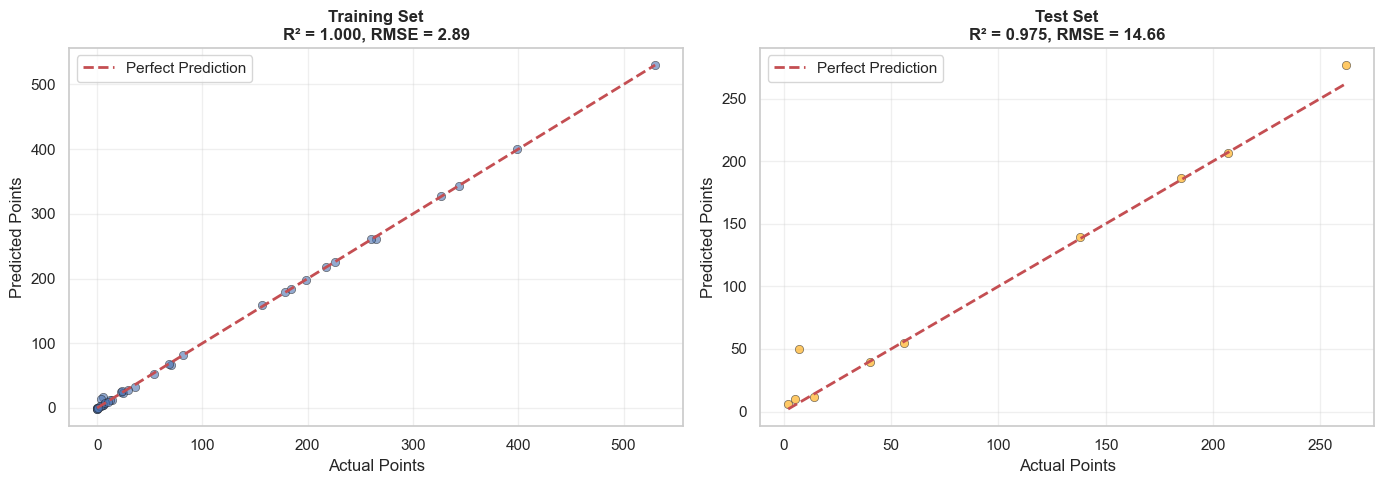

In [30]:
plot_model_performance(y_train, y_pred_train, y_test, y_pred_test, metrics)

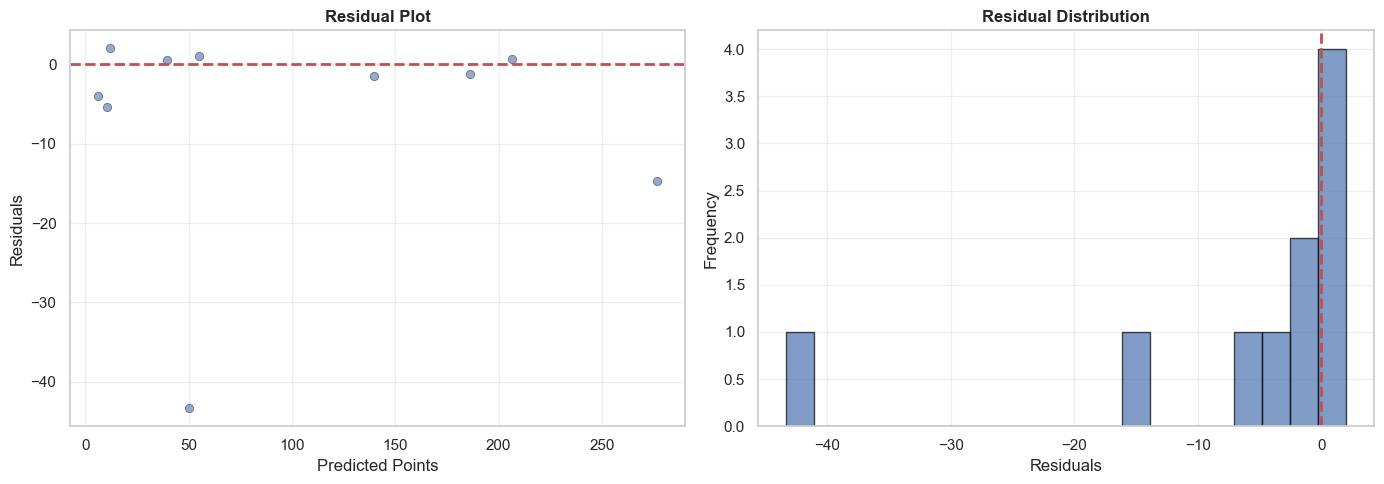

In [31]:
plot_residuals(y_test, y_pred_test)


Feature Importance (Regression Coefficients):
              feature  coefficient
3          PodiumRate    59.207697
0           AvgPoints    23.935709
5             DNFRate    16.707885
1           AvgFinish     0.487831
10    PrevYearPodiums     0.347780
2             AvgGrid     0.161738
9      PrevYearPoints     0.081474
7    RollingAvgPoints    -0.035758
6   AvgPositionChange    -0.326093
4             WinRate    -7.715021
8   RollingPodiumRate   -70.486351


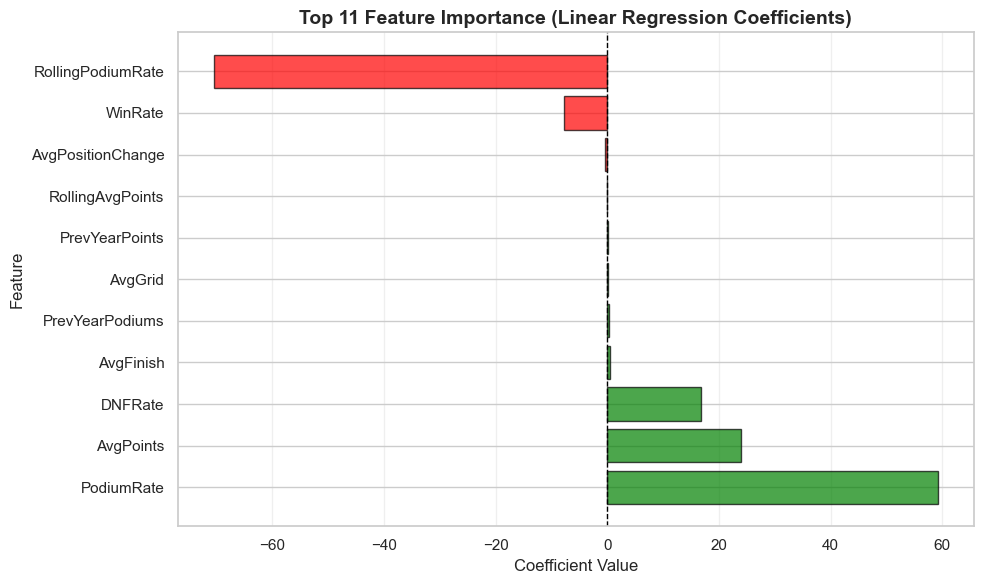

In [32]:
print("\nFeature Importance (Regression Coefficients):")
print(feature_importance)

plot_feature_importance(feature_importance, top_n=11)

In [33]:
# Create DataFrame with predictions
results_df = pd.DataFrame({
    'Actual': y_test. values,
    'Predicted':  y_pred_test,
    'Error': y_test.values - y_pred_test,
    'AbsError': np.abs(y_test.values - y_pred_test)
})

results_df = results_df.sort_values('AbsError', ascending=False)

print("\nWorst Predictions (Highest Absolute Error):")
print(results_df. head(10))

print("\nBest Predictions (Lowest Absolute Error):")
print(results_df.tail(10))


Worst Predictions (Highest Absolute Error):
   Actual   Predicted      Error   AbsError
4     7.0   50.318965 -43.318965  43.318965
9   262.0  276.761863 -14.761863  14.761863
7     5.0   10.345946  -5.345946   5.345946
2     2.0    5.988150  -3.988150   3.988150
3    14.0   12.012724   1.987276   1.987276
5   138.0  139.520911  -1.520911   1.520911
6   185.0  186.292031  -1.292031   1.292031
8    56.0   55.039130   0.960870   0.960870
1   207.0  206.404567   0.595433   0.595433
0    40.0   39.501867   0.498133   0.498133

Best Predictions (Lowest Absolute Error):
   Actual   Predicted      Error   AbsError
4     7.0   50.318965 -43.318965  43.318965
9   262.0  276.761863 -14.761863  14.761863
7     5.0   10.345946  -5.345946   5.345946
2     2.0    5.988150  -3.988150   3.988150
3    14.0   12.012724   1.987276   1.987276
5   138.0  139.520911  -1.520911   1.520911
6   185.0  186.292031  -1.292031   1.292031
8    56.0   55.039130   0.960870   0.960870
1   207.0  206.404567   0.595433

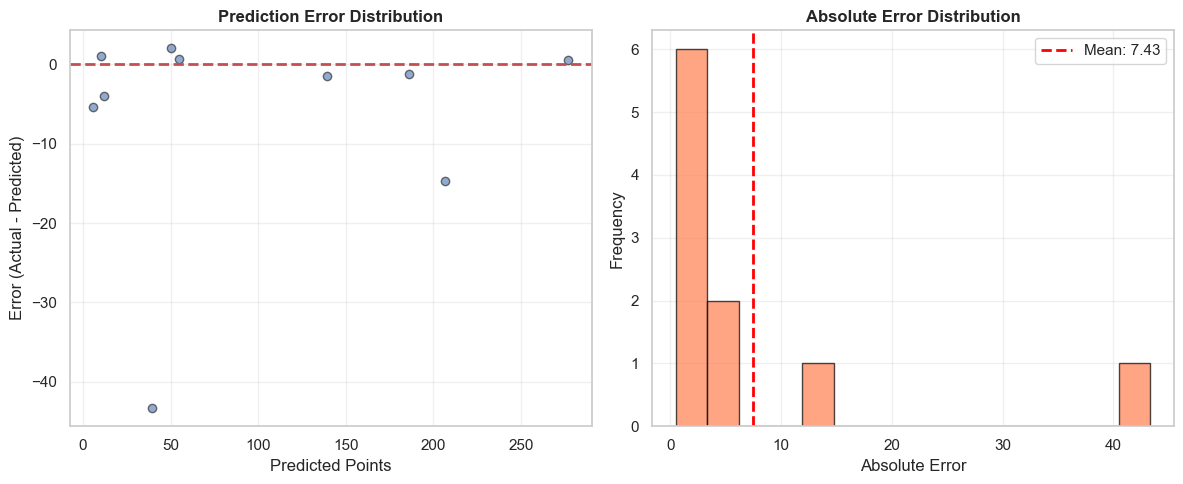

In [34]:
plt.figure(figsize=(12, 5))

# Error by predicted value
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, results_df['Error'], alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Points')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Prediction Error Distribution', fontweight='bold')
plt.grid(alpha=0.3)

# Absolute error distribution
plt.subplot(1, 2, 2)
plt.hist(results_df['AbsError'], bins=15, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Absolute Error Distribution', fontweight='bold')
plt.axvline(x=results_df['AbsError'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {results_df["AbsError"].mean():.2f}')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Save model to disk
model_path = "../models/linear_regression_model.pkl"
save_model(model, model_path)

# Also save metrics
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("../models/model_metrics.csv", index=False)
print(f" Model metrics saved")

# Save feature importance
feature_importance.to_csv("../models/feature_importance.csv", index=False)
print(f" Model feature importance saved")

✓ Model saved to ../models/linear_regression_model.pkl
 Model metrics saved
 Model feature importance saved
